In [ ]:
%pip install scikit-learn pandas nltk matplotlib seaborn

In [1]:
import pickle
import re
import time

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/imakarov/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/imakarov/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/imakarov/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
DATA_DIR = "./data"
TRAIN_PATH = f"{DATA_DIR}/balanced_train.csv"
TEST_PATH = f"{DATA_DIR}/balanced_test.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print(f"Training set: {len(df_train)} records, {df_train['condition'].nunique()} conditions")
print(f"Test set:     {len(df_test)} records, {df_test['condition'].nunique()} conditions")
print(f"\nTrain class distribution:\n{df_train['condition'].value_counts()}")
df_train[["drugName", "condition", "review"]].head()

Training set: 29489 records, 10 conditions
Test set:     22070 records, 10 conditions

Train class distribution:
condition
Anxiety            3522
Birth Control      3522
Pain               3522
Depression         3522
Acne               3198
Bipolar Disorde    2693
Insomnia           2639
Weight Loss        2474
Obesity            2325
ADHD               2072
Name: count, dtype: int64


,drugName,condition,review
0,Hydroxyzine,Anxiety,"""This drug does well for the purpose it was pr..."
1,Olanzapine,Bipolar Disorde,"""Zyprexa has given me my life back in 4 weeks!..."
2,NuvaRing,Birth Control,"""Went on the ring two years ago. Was ok with i..."
3,Etonogestrel,Birth Control,"""I got Nexplanon 10/25/12 2 weeks after the bi..."
4,Tramadol,Pain,"""Tramadol made me so queasy that I couldn't si..."


In [3]:
STOP_WORDS = frozenset(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()
DRUG_PLACEHOLDER = "[DRUGNAME]"


def preprocess_review(text: str, drug_name: str) -> str:
    """SVC preprocessing: mask drug name, lowercase, remove punctuation,
    remove stop words, lemmatize."""
    if pd.isna(text) or not str(text).strip():
        return ""

    text = str(text)

    if pd.notna(drug_name) and str(drug_name).strip():
        pattern = r"\b" + re.escape(str(drug_name)) + r"\b"
        text = re.sub(pattern, DRUG_PLACEHOLDER, text, flags=re.IGNORECASE)

    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)
    tokens = [
        LEMMATIZER.lemmatize(tok)
        for tok in tokens
        if tok not in STOP_WORDS and len(tok) > 1
    ]

    return " ".join(tokens)


sample = df_train.iloc[0]
print(f"Original:    {sample['review']}")
print(f"Drug name:   {sample['drugName']}")
print(f"Preprocessed: {preprocess_review(sample['review'], sample['drugName'])}")

Original:    "This drug does well for the purpose it was prescribed for: reduction of anxiety. However I commonly suffer from sleep walking, sleep motions and even talking. This drug really kicked all of that into overdrive. I spend the night having nightmares and constantly waking myself and my girlfriend up because I will scream at the top of my lungs as well as kick and punch the bed. If you have sleep issues like me I would not recommend it. If you do not then I would recommend it."
Drug name:   Hydroxyzine
Preprocessed: drug well purpose prescribed reduction anxiety however commonly suffer sleep walking sleep motion even talking drug really kicked overdrive spend night nightmare constantly waking girlfriend scream top lung well kick punch bed sleep issue like would recommend would recommend


In [4]:
start = time.time()

df_train["review_clean"] = df_train.apply(
    lambda row: preprocess_review(row["review"], row["drugName"]),
    axis=1,
)
print(f"Train preprocessing done in {time.time() - start:.1f}s")

start = time.time()

df_test["review_clean"] = df_test.apply(
    lambda row: preprocess_review(row["review"], row["drugName"]),
    axis=1,
)
print(f"Test preprocessing done in {time.time() - start:.1f}s")

print(f"\nTrain empty reviews after preprocessing: {(df_train['review_clean'] == '').sum()}")
print(f"Test empty reviews after preprocessing:  {(df_test['review_clean'] == '').sum()}")

df_train[["review", "review_clean"]].head(3)

Train preprocessing done in 8.0s
Test preprocessing done in 6.8s

Train empty reviews after preprocessing: 0
Test empty reviews after preprocessing:  0


,review,review_clean
0,"""This drug does well for the purpose it was pr...",drug well purpose prescribed reduction anxiety...
1,"""Zyprexa has given me my life back in 4 weeks!...",zyprexa given life back week worst panic attac...
2,"""Went on the ring two years ago. Was ok with i...",went ring two year ago ok baby year noticed ga...


In [5]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 1),
    max_features=20_000,
    sublinear_tf=True,
    min_df=3,
    max_df=0.95,
)

X_train = tfidf.fit_transform(df_train["review_clean"])
X_test = tfidf.transform(df_test["review_clean"])

y_train = df_train["condition"]
y_test = df_test["condition"]

print(f"TF-IDF vocabulary size: {len(tfidf.vocabulary_)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

TF-IDF vocabulary size: 9980
X_train shape: (29489, 9980)
X_test shape:  (22070, 9980)


In [6]:
svc_default = SVC(kernel="linear", C=1.0, random_state=42)

start = time.time()
svc_default.fit(X_train, y_train)
elapsed = time.time() - start
print(f"SVC(kernel='linear', C=1.0) trained in {elapsed:.1f}s")

y_pred_default = svc_default.predict(X_test)
acc_default = accuracy_score(y_test, y_pred_default)
print(f"Default model accuracy: {0.8422:.4f}")
print(f"\n{classification_report(y_test, y_pred_default)}")

SVC(kernel='linear', C=1.0) trained in 82.4s
Default model accuracy: 0.8422

                 precision    recall  f1-score   support

           ADHD       0.90      0.88      0.89       980
           Acne       0.87      0.93      0.90      1693
        Anxiety       0.73      0.79      0.76      1747
Bipolar Disorde       0.74      0.79      0.76      1236
  Birth Control       0.99      0.94      0.96      8402
     Depression       0.79      0.77      0.78      2798
       Insomnia       0.82      0.88      0.85      1127
        Obesity       0.68      0.70      0.69      1054
           Pain       0.90      0.93      0.91      1896
    Weight Loss       0.72      0.71      0.72      1137

       accuracy                           0.87     22070
      macro avg       0.81      0.83      0.82     22070
   weighted avg       0.87      0.87      0.87     22070



In [8]:
param_grid = {"C": [0.01, 0.1, 1.0, 10.0]}

grid_search = GridSearchCV(
    SVC(kernel="linear", random_state=42),
    param_grid,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    n_jobs=-1,
)

start = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"\nGridSearchCV completed in {elapsed:.1f}s")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV f1_macro: {grid_search.best_score_:.4f}")

cv_results = pd.DataFrame(grid_search.cv_results_)[
    ["param_C", "mean_test_score", "std_test_score", "mean_fit_time"]
]
print(f"\nAll CV results:\n{cv_results.to_string(index=False)}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ..............................................C=1.0; total time= 1.4min
[CV] END ..............................................C=1.0; total time= 1.5min
[CV] END ..............................................C=1.0; total time= 1.5min
[CV] END .............................................C=10.0; total time= 1.5min
[CV] END ..............................................C=0.1; total time= 2.3min
[CV] END ..............................................C=0.1; total time= 2.5min
[CV] END ..............................................C=0.1; total time= 2.5min
[CV] END .............................................C=10.0; total time= 1.3min
[CV] END .............................................C=10.0; total time= 1.3min
[CV] END .............................................C=0.01; total time= 3.8min
[CV] END .............................................C=0.01; total time= 3.8min
[CV] END ........................................

In [7]:
# THE BEST C is 1.0
# best_c = grid_search.best_params_["C"]
best_c = 1.0

svc_best = SVC(
    kernel="linear",
    C=best_c,
    probability=True,
    random_state=42,
)

start = time.time()
svc_best.fit(X_train, y_train)
elapsed = time.time() - start
print(f"Best SVC (C={best_c}, probability=True) trained in {elapsed:.1f}s")

y_pred = svc_best.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

Best SVC (C=1.0, probability=True) trained in 407.1s
Test accuracy: 0.8221

Classification Report:
                 precision    recall  f1-score   support

           ADHD       0.90      0.88      0.89       980
           Acne       0.87      0.93      0.90      1693
        Anxiety       0.73      0.79      0.76      1747
Bipolar Disorde       0.74      0.79      0.76      1236
  Birth Control       0.99      0.94      0.96      8402
     Depression       0.79      0.77      0.78      2798
       Insomnia       0.82      0.88      0.85      1127
        Obesity       0.68      0.70      0.69      1054
           Pain       0.90      0.93      0.91      1896
    Weight Loss       0.72      0.71      0.72      1137

       accuracy                           0.87     22070
      macro avg       0.81      0.83      0.82     22070
   weighted avg       0.87      0.87      0.87     22070



In [8]:
with open("./models/svc_model.pkl", "wb") as f:
    pickle.dump(svc_best, f)
with open("./models/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("\nModel and vectorizer saved to ./models/")


Model and vectorizer saved to ./models/


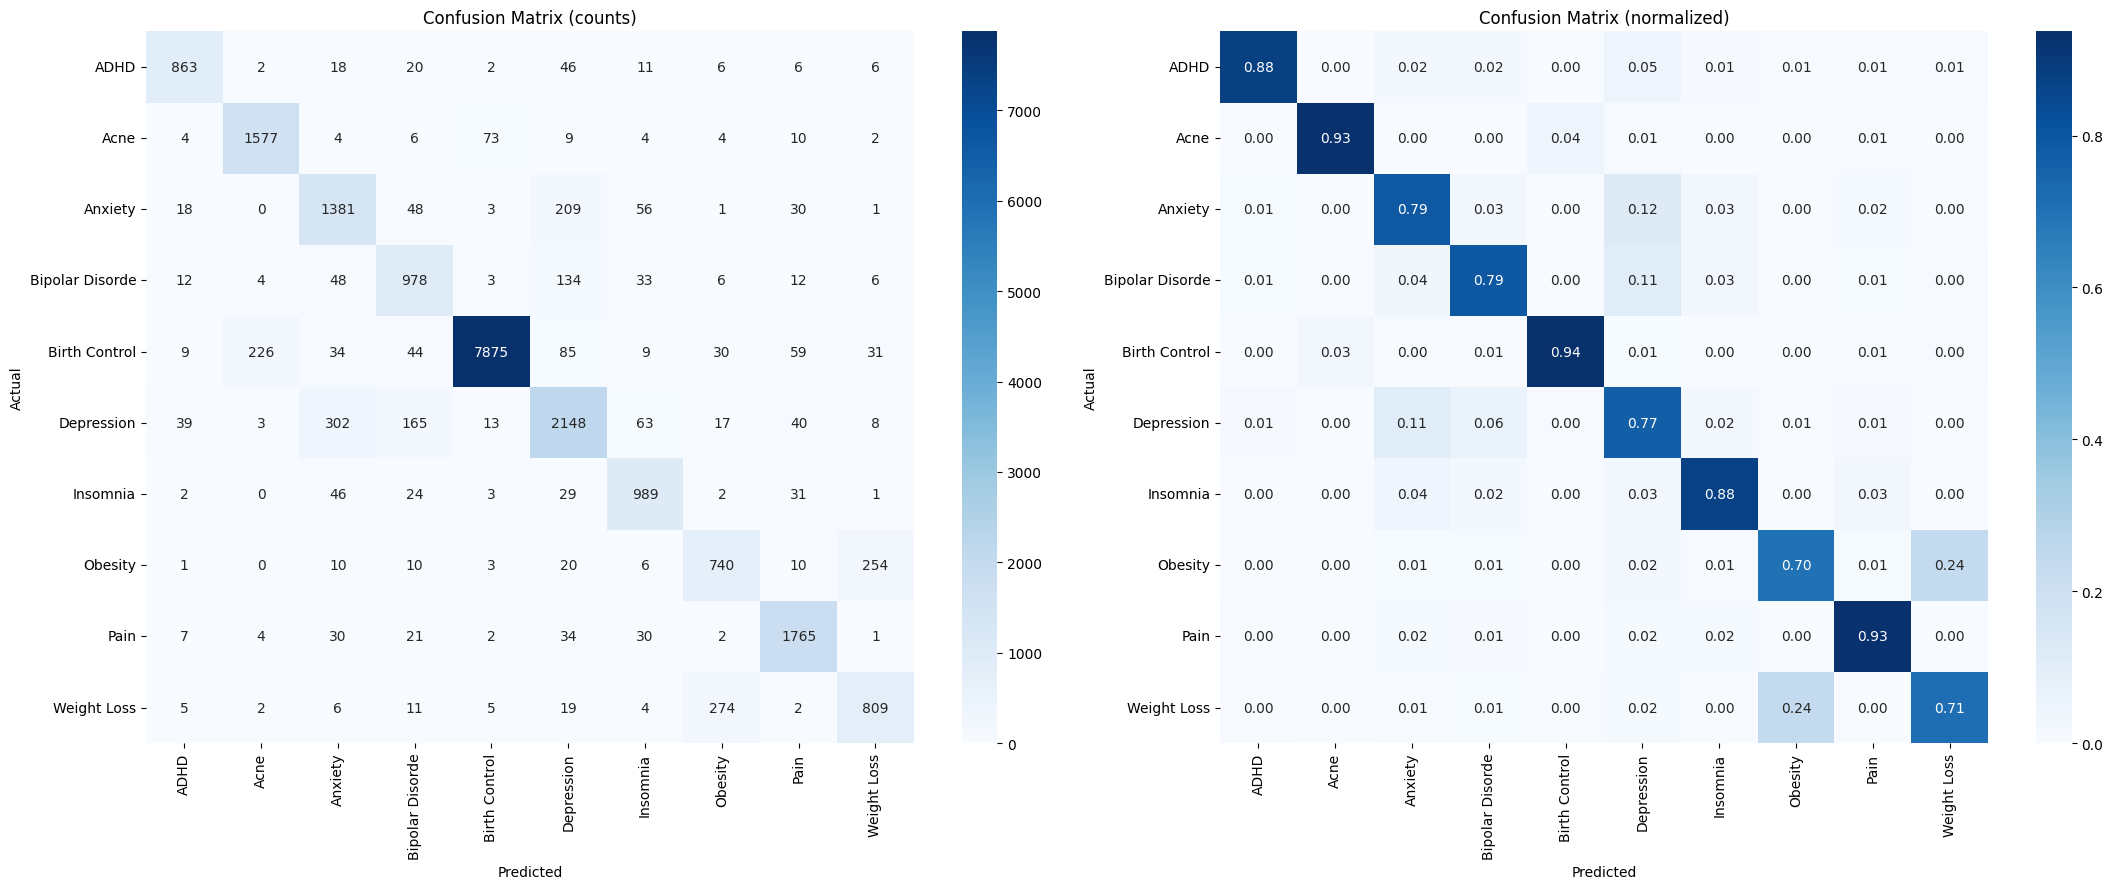

In [10]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1],
)
axes[1].set_title("Confusion Matrix (normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()